<a href="https://colab.research.google.com/github/yokubova/week12_LAB/blob/main/Gradient_Descent_and_Polynomial_Regression_Lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Gradient Descent and Polynomial Regression

## Overview
In this lab, you will learn how to implement and compare three core optimization strategies used in machine learning:

- **Batch Gradient Descent (BGD)**
- **Stochastic Gradient Descent (SGD)**
- **Mini-Batch Gradient Descent (MBGD)**

You will first study the underlying mathematics and implement these methods **from scratch with NumPy**.
Then you will apply them to **polynomial regression**, analyze their behavior, and complete hands-on exercises.

## Learning Objectives
By the end of this lab, you should be able to:

1. Explain how gradient descent minimizes a cost function.
2. Derive and implement update rules for BGD, SGD, and MBGD.
3. Build polynomial features for nonlinear curve fitting.
4. Compare optimization methods in terms of speed, stability, and final performance.
5. Critically evaluate hyperparameters such as learning rate and batch size.

In [1]:
# =============================
# Imports and visual settings
# =============================
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

sns.set_theme(style="whitegrid", context="notebook")
np.random.seed(42)

print("Libraries imported successfully.")

Libraries imported successfully.


## 1) Gradient Descent: Concept and Mathematics

### Why Gradient Descent?
For many machine learning models, we define a loss (or cost) function and want to find model parameters that minimize it.
Gradient descent is an iterative optimization algorithm that updates parameters in the direction of the **negative gradient** of the loss.

### Linear Model Form
We use a hypothesis:

$$
\hat{y} = X\theta
$$

where:
- $X \in \mathbb{R}^{m \times n}$ is the design matrix,
- $\theta \in \mathbb{R}^{n \times 1}$ are model parameters,
- $\hat{y} \in \mathbb{R}^{m \times 1}$ are predictions.

### Cost Function (Mean Squared Error)

$$
J(\theta) = \frac{1}{2m} \sum_{i=1}^{m}(\hat{y}^{(i)} - y^{(i)})^2
$$

In matrix form:

$$
J(\theta) = \frac{1}{2m}(X\theta - y)^T(X\theta - y)
$$

### Gradient of MSE

$$
\nabla_\theta J(\theta) = \frac{1}{m}X^T(X\theta - y)
$$

### Update Rule

$$
\theta := \theta - \eta \nabla_\theta J(\theta)
$$

where $\eta$ is the learning rate.

---

## Three Variants

1. **Batch GD**: Uses all training examples each update.
   $$
   \theta := \theta - \eta \cdot \frac{1}{m}X^T(X\theta - y)
   $$

2. **Stochastic GD (SGD)**: Uses one sample at a time.
   $$
   \theta := \theta - \eta \cdot x_i^T(x_i\theta - y_i)
   $$

3. **Mini-Batch GD**: Uses a small batch $B$ each update.
   $$
   \theta := \theta - \eta \cdot \frac{1}{|B|}X_B^T(X_B\theta - y_B)
   $$

Trade-off intuition:
- Batch: stable but can be slow per update.
- SGD: fast, noisy updates.
- Mini-Batch: balanced and widely used in practice.

In [2]:
class GradientDescentRegressor:
    """
    Linear regressor optimized using batch, stochastic, or mini-batch GD.
    """
    def __init__(self, method="batch", lr=0.01, epochs=200, batch_size=32, random_state=42):
        self.method = method
        self.lr = lr
        self.epochs = epochs
        self.batch_size = batch_size
        self.random_state = random_state
        self.theta = None
        self.loss_history = []
        self.training_time = None

    def _compute_gradient(self, X, y):
        """Gradient of MSE cost with respect to theta."""
        m = X.shape[0]
        errors = X @ self.theta - y
        grad = (X.T @ errors) / m
        return grad

    def fit(self, X, y):
        """Train model parameters using selected GD method."""
        rng = np.random.default_rng(self.random_state)
        m, n = X.shape
        self.theta = np.zeros((n, 1))
        self.loss_history = []

        start = time.perf_counter()

        for epoch in range(self.epochs):
            if self.method == "batch":
                grad = self._compute_gradient(X, y)
                self.theta -= self.lr * grad

            elif self.method == "sgd":
                # Shuffle indices each epoch for better stochastic behavior.
                indices = rng.permutation(m)
                for i in indices:
                    Xi = X[i:i+1]
                    yi = y[i:i+1]
                    grad = Xi.T @ (Xi @ self.theta - yi)  # batch size is 1
                    self.theta -= self.lr * grad

            elif self.method == "mini-batch":
                indices = rng.permutation(m)
                for start_idx in range(0, m, self.batch_size):
                    batch_idx = indices[start_idx:start_idx + self.batch_size]
                    Xb = X[batch_idx]
                    yb = y[batch_idx]
                    grad = (Xb.T @ (Xb @ self.theta - yb)) / Xb.shape[0]
                    self.theta -= self.lr * grad

            else:
                raise ValueError("method must be 'batch', 'sgd', or 'mini-batch'")

            # Track full-dataset loss after each epoch.
            y_pred_epoch = X @ self.theta
            epoch_loss = mean_squared_error(y, y_pred_epoch)
            self.loss_history.append(epoch_loss)

        end = time.perf_counter()
        self.training_time = end - start
        return self

    def predict(self, X):
        """Predict targets for input matrix X."""
        return X @ self.theta

## 2) Simple Example: Compare BGD, SGD, and MBGD

We start with a simple linear dataset to compare convergence behavior of the three methods.

Model: $y = 4 + 3x + \epsilon$

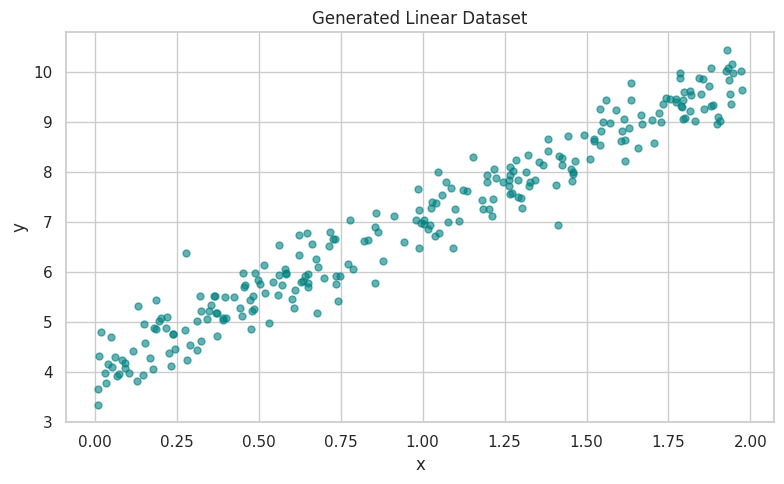

,Method,Final MSE,Training Time (s),Final Theta
0,Batch GD,0.218234,0.066049,"[3.606754282347466, 3.3500936172456846]"
1,SGD,0.156999,0.254515,"[4.072970623899527, 2.9471973098206514]"
2,Mini-Batch GD,0.157060,0.050955,"[4.054809763947758, 2.9712473416164924]"


In [3]:
# Generate synthetic linear data
m = 250
X_raw = 2 * np.random.rand(m, 1)
noise = np.random.randn(m, 1) * 0.4
y = 4 + 3 * X_raw + noise

# Visualize dataset immediately after generation
plt.figure(figsize=(8, 5))
plt.scatter(X_raw, y, alpha=0.6, s=25, color="teal")
plt.title("Generated Linear Dataset")
plt.xlabel("x")
plt.ylabel("y")
plt.tight_layout()
plt.show()

# Add bias term for linear model
X = np.c_[np.ones((X_raw.shape[0], 1)), X_raw]

# Train all three variants
models = {
    "Batch GD": GradientDescentRegressor(method="batch", lr=0.08, epochs=50),
    "SGD": GradientDescentRegressor(method="sgd", lr=0.01, epochs=50),
    "Mini-Batch GD": GradientDescentRegressor(method="mini-batch", lr=0.03, epochs=50, batch_size=16)
}

results_simple = []

for name, model in models.items():
    model.fit(X, y)
    y_pred = model.predict(X)
    results_simple.append({
        "Method": name,
        "Final MSE": mean_squared_error(y, y_pred),
        "Training Time (s)": model.training_time,
        "Final Theta": model.theta.ravel()
    })

simple_results_df = pd.DataFrame(results_simple)
simple_results_df

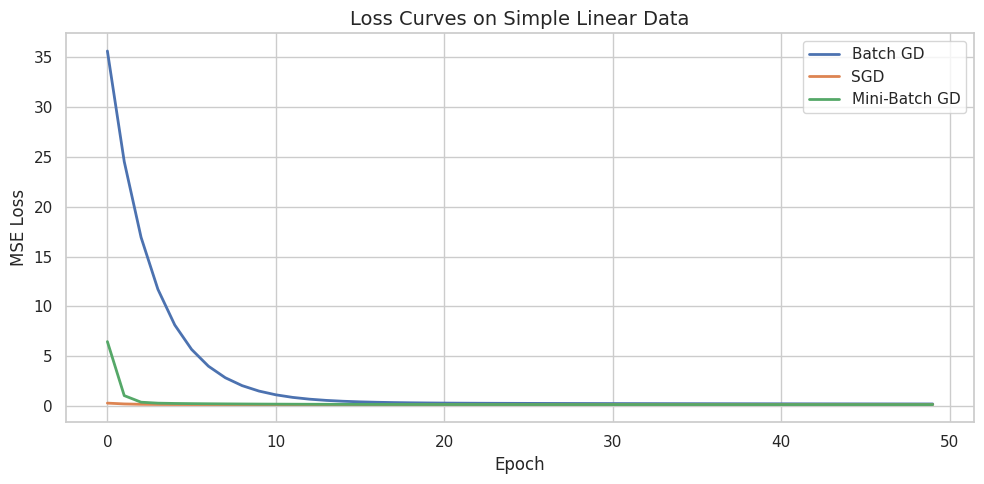

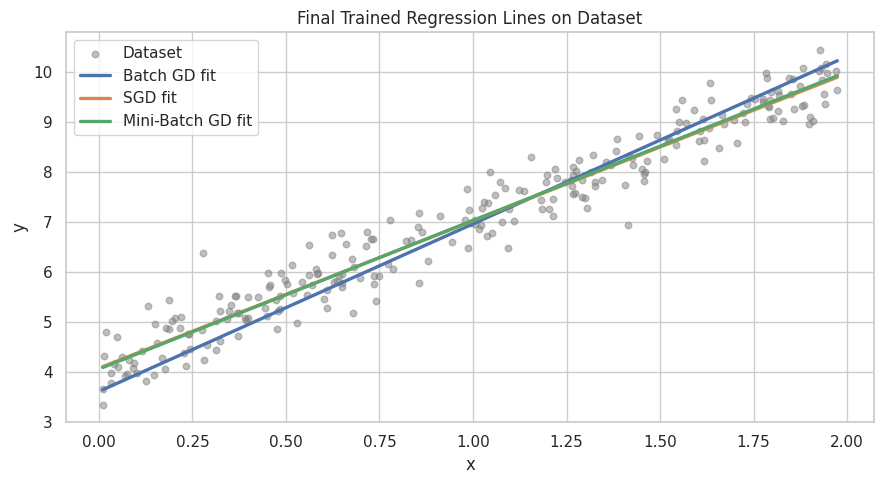

,Method,Final MSE,Training Time (s),Final Theta
1,SGD,0.156999,0.254515,"[4.072970623899527, 2.9471973098206514]"
2,Mini-Batch GD,0.157060,0.050955,"[4.054809763947758, 2.9712473416164924]"
0,Batch GD,0.218234,0.066049,"[3.606754282347466, 3.3500936172456846]"


In [4]:
# Plot loss curves to compare convergence
plt.figure(figsize=(10, 5))
for name, model in models.items():
    plt.plot(model.loss_history, label=name, linewidth=2)

plt.title("Loss Curves on Simple Linear Data", fontsize=14)
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.tight_layout()
plt.show()

# Visualize final trained regression lines on top of the dataset
x_line = np.linspace(X_raw.min(), X_raw.max(), 300).reshape(-1, 1)
X_line = np.c_[np.ones((x_line.shape[0], 1)), x_line]

plt.figure(figsize=(9, 5))
plt.scatter(X_raw, y, alpha=0.5, s=22, color="gray", label="Dataset")
for name, model in models.items():
    y_line_pred = model.predict(X_line)
    plt.plot(x_line, y_line_pred, linewidth=2.4, label=f"{name} fit")

plt.title("Final Trained Regression Lines on Dataset")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.tight_layout()
plt.show()

display(simple_results_df.sort_values("Final MSE"))

### Interpretation
- **Batch GD** usually gives smoother convergence because each update uses the full dataset.
- **SGD** often converges quickly at first but exhibits noisier loss curves.
- **Mini-Batch GD** balances stability and computational efficiency.

In practice, mini-batch methods are widely used because they are GPU-friendly and often converge well.

## 3) Polynomial Regression from Scratch

### Why Polynomial Features?
A linear model in the original feature space can only fit straight lines/planes.
If the relationship between $x$ and $y$ is nonlinear, we can map input $x$ to polynomial features:

$$
\phi(x) = [x, x^2, x^3, \dots, x^d]
$$

Then fit a linear model in transformed space:

$$
\hat{y} = \theta_0 + \theta_1 x + \theta_2 x^2 + \cdots + \theta_d x^d
$$

This is still linear in parameters $\theta$, so gradient descent applies directly.

In [16]:
m_poly = 300
x_poly = np.random.uniform(-3, 3, size=(m_poly, 1))
y_poly = 1.5 - 2.0 * x_poly + 0.9 * (x_poly ** 2) + 0.2 * (x_poly ** 3) + 0.3 * (x_poly ** 4)  + np.random.randn(m_poly, 1) * 1.2

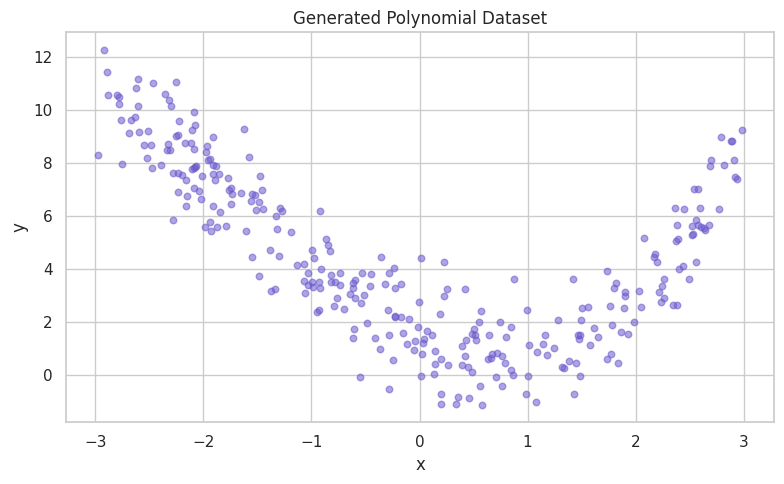

Polynomial data prepared.
Design matrix shape: (300, 4)


In [5]:
# Generate synthetic polynomial data
m_poly = 300
x_poly = np.random.uniform(-3, 3, size=(m_poly, 1))
y_poly = 1.5 - 2.0 * x_poly + 0.9 * (x_poly ** 2) + 0.2 * (x_poly ** 3) + np.random.randn(m_poly, 1) * 1.2

# Visualize dataset immediately after generation
plt.figure(figsize=(8, 5))
plt.scatter(x_poly, y_poly, alpha=0.55, s=22, color="slateblue")
plt.title("Generated Polynomial Dataset")
plt.xlabel("x")
plt.ylabel("y")
plt.tight_layout()
plt.show()

# Create polynomial features up to degree 3 using sklearn
degree = 3
poly = PolynomialFeatures(degree=degree, include_bias=False)
X_poly_raw = poly.fit_transform(x_poly)

# Standardize polynomial features for stable GD updates using sklearn
scaler = StandardScaler()
X_poly_scaled = scaler.fit_transform(X_poly_raw)

# Add explicit bias for our from-scratch GD implementation
X_poly_design = np.c_[np.ones((X_poly_scaled.shape[0], 1)), X_poly_scaled]

print("Polynomial data prepared.")
print("Design matrix shape:", X_poly_design.shape)

In [6]:
# Train polynomial regression with all three GD variants
poly_models = {
    "Batch GD": GradientDescentRegressor(method="batch", lr=0.05, epochs=250),
    "SGD": GradientDescentRegressor(method="sgd", lr=0.005, epochs=250),
    "Mini-Batch GD": GradientDescentRegressor(method="mini-batch", lr=0.02, epochs=250, batch_size=32)
}

poly_results = []
for name, model in poly_models.items():
    model.fit(X_poly_design, y_poly)
    y_pred = model.predict(X_poly_design)

    # Convergence criterion example: first epoch where loss <= 1.05 * final loss
    final_loss = model.loss_history[-1]
    threshold = 1.05 * final_loss
    epochs_to_converge = next((i + 1 for i, l in enumerate(model.loss_history) if l <= threshold), model.epochs)

    poly_results.append({
        "Method": name,
        "Final MSE": mean_squared_error(y_poly, y_pred),
        "Epochs to Converge": epochs_to_converge,
        "Training Time (s)": model.training_time
    })

poly_results_df = pd.DataFrame(poly_results)
poly_results_df

,Method,Final MSE,Epochs to Converge,Training Time (s)
0,Batch GD,1.424179,195,0.166074
1,SGD,1.292687,12,0.856412
2,Mini-Batch GD,1.292398,86,0.140505


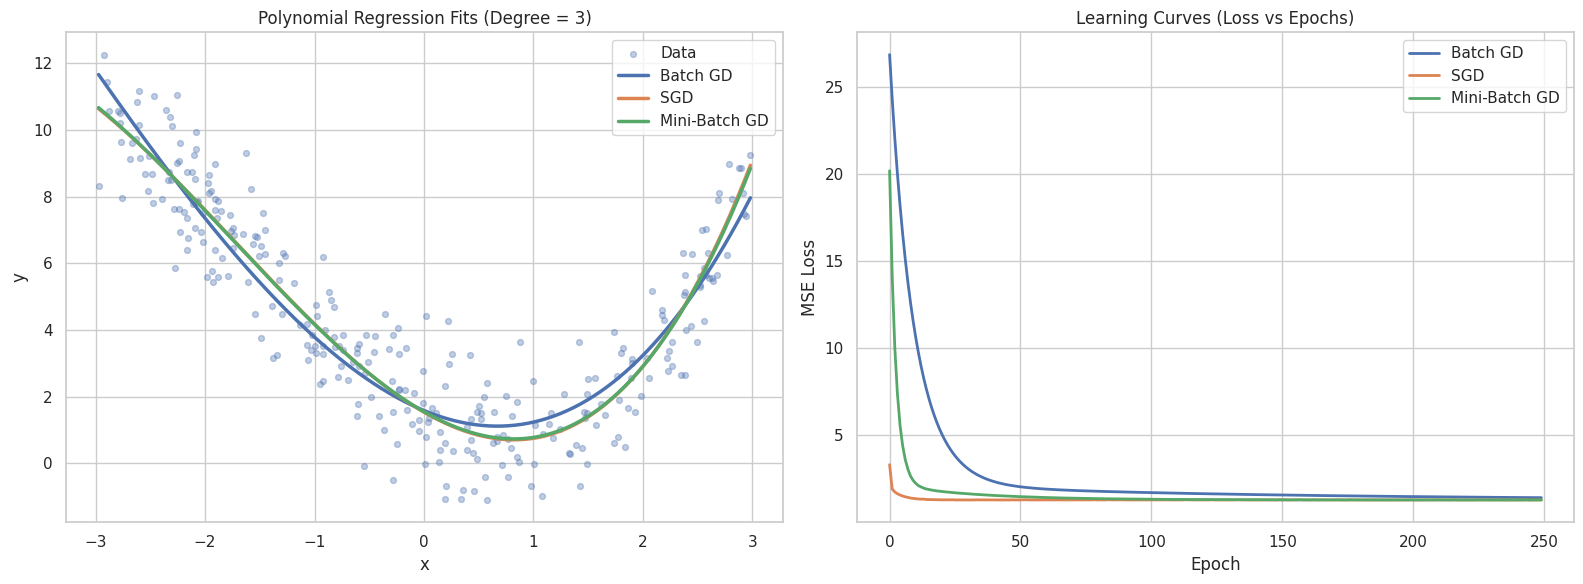

,Method,Final MSE,Epochs to Converge,Training Time (s)
2,Mini-Batch GD,1.292398,86,0.140505
1,SGD,1.292687,12,0.856412
0,Batch GD,1.424179,195,0.166074


In [7]:
# Visualize fitted curves and learning curves
x_grid = np.linspace(x_poly.min(), x_poly.max(), 400).reshape(-1, 1)
X_grid_raw = poly.transform(x_grid)
X_grid_scaled = scaler.transform(X_grid_raw)
X_grid_design = np.c_[np.ones((X_grid_scaled.shape[0], 1)), X_grid_scaled]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: data + fitted curves
axes[0].scatter(x_poly, y_poly, alpha=0.35, s=18, label="Data")
for name, model in poly_models.items():
    y_grid_pred = model.predict(X_grid_design)
    axes[0].plot(x_grid, y_grid_pred, linewidth=2.5, label=name)

axes[0].set_title("Polynomial Regression Fits (Degree = 3)")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
axes[0].legend()

# Right: learning curves
for name, model in poly_models.items():
    axes[1].plot(model.loss_history, linewidth=2, label=name)

axes[1].set_title("Learning Curves (Loss vs Epochs)")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("MSE Loss")
axes[1].legend()

plt.tight_layout()
plt.show()

display(poly_results_df.sort_values("Final MSE"))

### Observations
- All three methods can fit polynomial regression when features are engineered properly.
- Feature scaling is critical for numerical stability, especially for high-degree polynomial terms.
- SGD may oscillate more due to noisy updates, while Batch GD is smoother.
- Mini-Batch GD often gives a strong practical compromise.

# 4) Lab Exercises (Total: 100 points)

Complete the following tasks. Write clean code, include plots, and explain your findings in markdown.

## Task 1 (25 points)
**Implement Batch Gradient Descent from scratch** for a 4nd-degree polynomial regression on a new synthetic dataset (use different coefficients and noise from tutorial).

### Requirements
- Generate your own dataset.
- Build polynomial features (degree 4).
- Train using Batch GD.
- Plot fitted curve and learning curve.

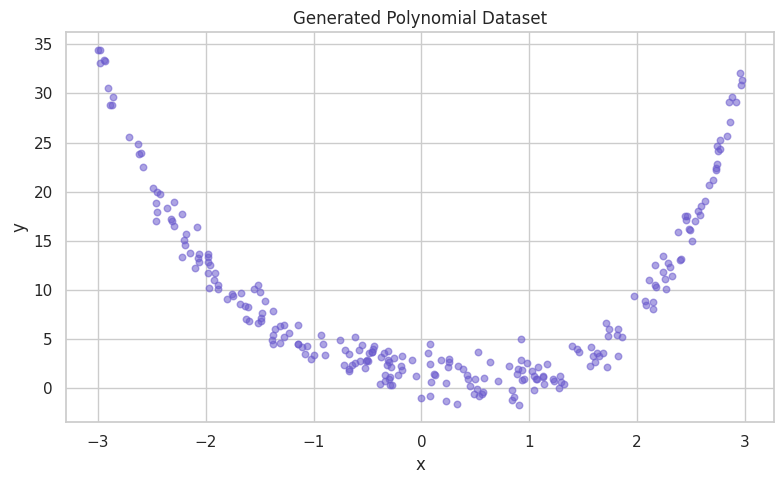

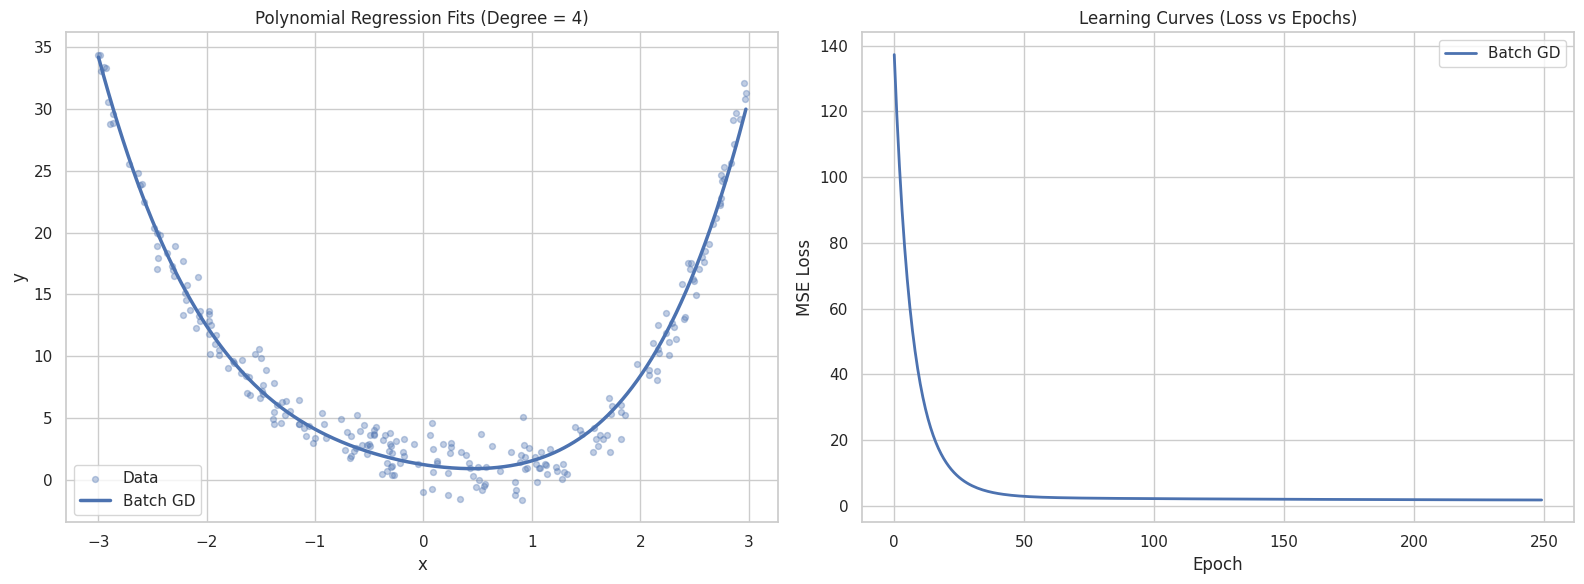

In [25]:
# -----------------------------
# Task 1 starter template
# -----------------------------
# TODO: Generate a new synthetic quadratic dataset with different coefficients/noise.
# Example target form: y = a + b*x + c*x^2 + d*x^3 + e*x^4 + noise
m_poly = 250
x_poly = np.random.uniform(-3, 3, size=(m_poly, 1))
y_poly = 1.5 - 2.0 * x_poly + 0.9 * (x_poly ** 2) + 0.2 * (x_poly ** 3) + 0.3 * (x_poly ** 4)  + np.random.randn(m_poly, 1) * 1.2

# Visualize dataset immediately after generation
plt.figure(figsize=(8, 5))
plt.scatter(x_poly, y_poly, alpha=0.55, s=22, color="slateblue")
plt.title("Generated Polynomial Dataset")
plt.xlabel("x")
plt.ylabel("y")
plt.tight_layout()
plt.show()


# TODO: Build degree-4 polynomial features and standardize using sklearn.
degree = 4
poly = PolynomialFeatures(degree=degree, include_bias=False)
X_poly_raw = poly.fit_transform(x_poly)

# Standardize polynomial features for stable GD updates using sklearn
# FIX: Instantiate StandardScaler here
scaler = StandardScaler()
X_poly_scaled = scaler.fit_transform(X_poly_raw)

# Add explicit bias for our from-scratch GD implementation
X_poly_design = np.c_[np.ones((X_poly_scaled.shape[0], 1)), X_poly_scaled]

# TODO: Train Batch GD.
poly_models = {
    "Batch GD": GradientDescentRegressor(method="batch", lr=0.05, epochs=250),
}

# FIX: Call the fit method on the model before predicting
for name, model in poly_models.items():
    model.fit(X_poly_design, y_poly)

# TODO: Plot fitted curve and loss curve.
x_grid = np.linspace(x_poly.min(), x_poly.max(), 400).reshape(-1, 1)
X_grid_raw = poly.transform(x_grid)
X_grid_scaled = scaler.transform(X_grid_raw)
X_grid_design = np.c_[np.ones((X_grid_scaled.shape[0], 1)), X_grid_scaled]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: data + fitted curves
axes[0].scatter(x_poly, y_poly, alpha=0.35, s=18, label="Data")
for name, model in poly_models.items():
    y_grid_pred = model.predict(X_grid_design)
    axes[0].plot(x_grid, y_grid_pred, linewidth=2.5, label=name)

# FIX: Update title to reflect correct degree
axes[0].set_title("Polynomial Regression Fits (Degree = 4)")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
axes[0].legend()

# Right: learning curves
for name, model in poly_models.items():
    axes[1].plot(model.loss_history, linewidth=2, label=name)

axes[1].set_title("Learning Curves (Loss vs Epochs)")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("MSE Loss")
axes[1].legend()

plt.tight_layout()
plt.show()

## Task 2 (25 points)
**Implement Stochastic Gradient Descent (SGD)** and tune the learning rate.

### Requirements
- Use one polynomial dataset.
- Try multiple learning rates (e.g., 0.0005, 0.001, 0.005, 0.01).
- Plot loss curves for each learning rate.
- Explain underfitting/divergence/instability if observed.

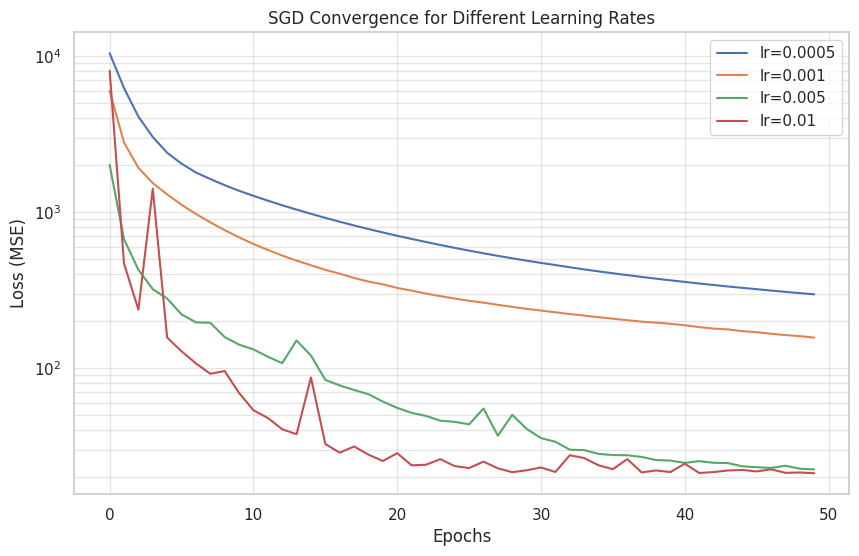

In [28]:
# -----------------------------
# Task 2 starter template
# -----------------------------
learning_rates = [0.0005, 0.001, 0.005, 0.01]
sgd_histories = {}

# TODO: Reuse or regenerate a polynomial dataset.


import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

# 1. Reuse/Regenerate the polynomial dataset (from Task 1)
np.random.seed(42)
n_samples = 100
x = 2 - 3 * np.random.normal(0, 1, n_samples).reshape(-1, 1)
y = 1 + 0.5*x - 2*(x**2) + 0.3*(x**3) + 0.1*(x**4) + np.random.normal(-5, 5, (n_samples, 1))

# Preprocess
poly = PolynomialFeatures(degree=4, include_bias=False)
x_poly = poly.fit_transform(x)
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x_poly)
X_b = np.c_[np.ones((n_samples, 1)), x_scaled] # Add bias

# 2. SGD Implementation and Hyperparameter Tuning
learning_rates = [0.0005, 0.001, 0.005, 0.01]
sgd_histories = {}
n_epochs = 50

for lr in learning_rates:
    theta = np.random.randn(5, 1)
    loss_history = []

    for epoch in range(n_epochs):
        # Shuffle data at the start of each epoch
        shuffled_indices = np.random.permutation(n_samples)
        X_b_shuffled = X_b[shuffled_indices]
        y_shuffled = y[shuffled_indices]

        for i in range(n_samples):
            xi = X_b_shuffled[i:i+1]
            yi = y_shuffled[i:i+1]

            # Gradient for a single instance
            gradients = 2 * xi.T.dot(xi.dot(theta) - yi)
            theta = theta - lr * gradients

        # Calculate MSE for the epoch to track progress
        current_loss = np.mean((X_b.dot(theta) - y)**2)
        loss_history.append(current_loss)

    sgd_histories[lr] = loss_history

# 3. Plot all loss curves on one figure
plt.figure(figsize=(10, 6))
for lr, history in sgd_histories.items():
    plt.plot(history, label=f'lr={lr}')

plt.yscale('log') # Log scale helps visualize divergence vs convergence
plt.title("SGD Convergence for Different Learning Rates")
plt.xlabel("Epochs")
plt.ylabel("Loss (MSE)")
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.show()

for lr in learning_rates:
    # TODO: Train SGD with each learning rate.
    pass

# TODO: Plot all loss curves on one figure.

# TODO: Add markdown analysis of learning-rate effects.

## Task 3 (25 points)
**Implement Mini-Batch Gradient Descent** and study different batch sizes.

### Requirements
- Try batch sizes: 8, 16, 32, 64.
- Keep other settings fixed (same learning rate, epochs, dataset).
- Plot loss curves for each batch size.
- Analyze trade-off: convergence speed vs stability.

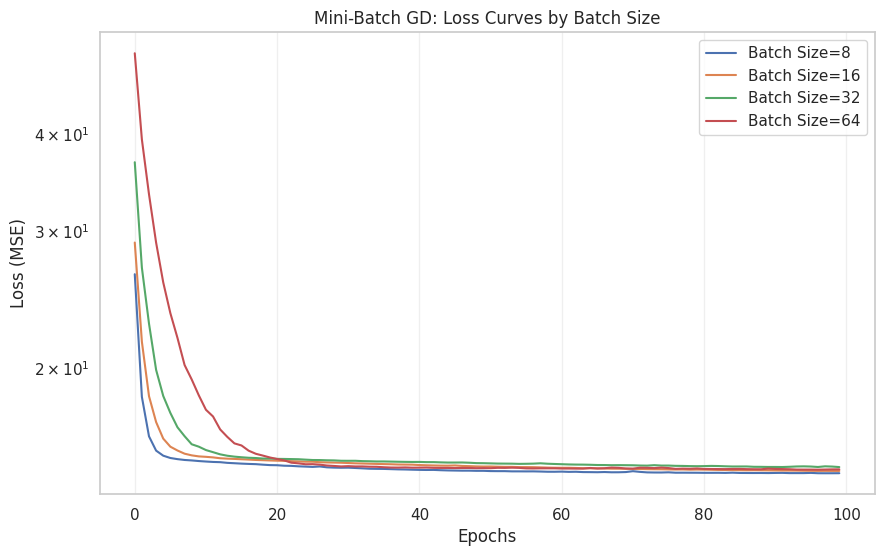

   Batch Size  Final MSE  Time (s)
0           8    14.6319    0.0425
1          16    14.7313    0.0254
2          32    14.9002    0.0172
3          64    14.8002    0.0132


In [29]:
# -----------------------------
# Task 3 starter template
# -----------------------------
batch_sizes = [8, 16, 32, 64]
mbgd_histories = {}
mbgd_metrics = []

# TODO: Reuse a consistent polynomial dataset from Task 2 or create one.
# X_t3, y_t3 = ...

for bs in batch_sizes:
    # TODO: Train Mini-Batch GD for each batch size.

    # mbgd_histories[bs] = model.loss_history
    # mbgd_metrics.append({"Batch Size": bs, "Final MSE": mean_squared_error(y_t3, model.predict(X_t3)), "Time": model.training_time})
    pass

# TODO: Plot loss curves and display metric table.
# pd.DataFrame(mbgd_metrics)

# TODO: Add markdown analysis about stability and speed.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.metrics import mean_squared_error

# 1. Reuse consistent polynomial dataset
np.random.seed(42)
n_samples = 200 # Slightly more samples to better see batch effects
x = np.random.uniform(-3, 3, (n_samples, 1))
y = 1 + 0.5*x - 2*(x**2) + 0.3*(x**3) + 0.1*(x**4) + np.random.normal(0, 4, (n_samples, 1))

# Preprocess
poly = PolynomialFeatures(degree=4, include_bias=False)
x_poly = poly.fit_transform(x)
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x_poly)
X_t3 = np.c_[np.ones((n_samples, 1)), x_scaled]
y_t3 = y

# 2. Mini-Batch GD Implementation
batch_sizes = [8, 16, 32, 64]
mbgd_histories = {}
mbgd_metrics = []

lr = 0.01 # Fixed learning rate
n_epochs = 100

for bs in batch_sizes:
    theta = np.random.randn(5, 1)
    loss_history = []
    start_time = time.time()

    for epoch in range(n_epochs):
        # Shuffle at the start of each epoch
        indices = np.random.permutation(n_samples)
        X_shuffled = X_t3[indices]
        y_shuffled = y_t3[indices]

        for i in range(0, n_samples, bs):
            xi = X_shuffled[i:i+bs]
            yi = y_shuffled[i:i+bs]

            # Gradient for the mini-batch
            m_batch = len(yi)
            gradients = 2/m_batch * xi.T.dot(xi.dot(theta) - yi)
            theta = theta - lr * gradients

        loss_history.append(np.mean((X_t3.dot(theta) - y_t3)**2))

    end_time = time.time()
    mbgd_histories[bs] = loss_history

    # Calculate final metrics
    final_mse = mean_squared_error(y_t3, X_t3.dot(theta))
    mbgd_metrics.append({
        "Batch Size": bs,
        "Final MSE": round(final_mse, 4),
        "Time (s)": round(end_time - start_time, 4)
    })

# 3. Plot loss curves
plt.figure(figsize=(10, 6))
for bs, history in mbgd_histories.items():
    plt.plot(history, label=f'Batch Size={bs}')

plt.yscale('log')
plt.title("Mini-Batch GD: Loss Curves by Batch Size")
plt.xlabel("Epochs")
plt.ylabel("Loss (MSE)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 4. Display metric table
df_metrics = pd.DataFrame(mbgd_metrics)
print(df_metrics)

## Task 4 (25 points)
**Compare Batch, SGD, and Mini-Batch GD** on the same polynomial regression dataset.

### Required comparison outputs
- Final MSE
- Number of epochs to converge
- Training time
- Final fitted curve quality (visual inspection)

Present a summary table and at least one comparison plot.

          Method  Final MSE  Training Time (s)  Epochs
0       Batch GD    10.3584             0.0033     100
1            SGD     9.0004             0.1923     100
2  Mini-Batch GD     8.8263             0.0181     100


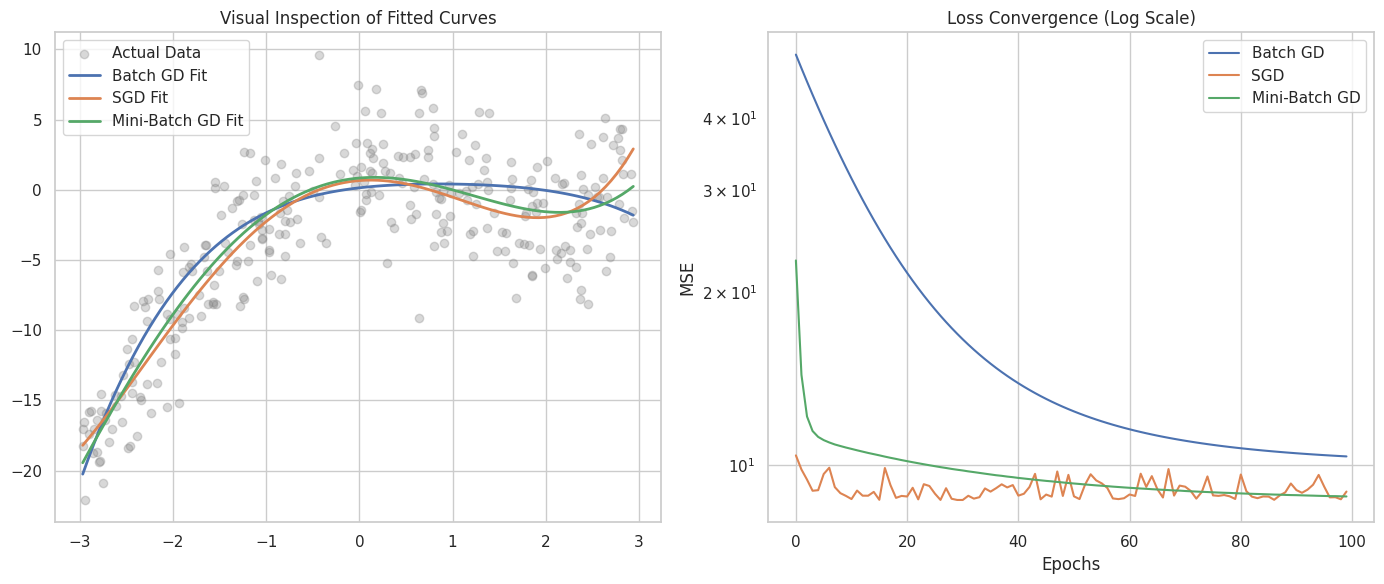

In [30]:
# -----------------------------
# Task 4 starter template
# -----------------------------
# TODO: Use one shared dataset and preprocessing.
# X_t4, y_t4 = ...

task4_models = {
    "Batch GD": GradientDescentRegressor(method="batch", lr=..., epochs=...),
    "SGD": GradientDescentRegressor(method="sgd", lr=..., epochs=...),
    "Mini-Batch GD": GradientDescentRegressor(method="mini-batch", lr=..., epochs=..., batch_size=...)
}

task4_rows = []
for name, model in task4_models.items():
    pass

# TODO: Build summary table and visualization.
# summary_df = pd.DataFrame(task4_rows)
# display(summary_df)

# TODO: Plot fitted curves on the same graph for qualitative comparison.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.metrics import mean_squared_error

# 1. Shared Dataset and Preprocessing
np.random.seed(42)
n_samples = 300
x = np.random.uniform(-3, 3, (n_samples, 1))
y = 1 + 0.5*x - 2*(x**2) + 0.3*(x**3) + 0.1*(x**4) + np.random.normal(0, 3, (n_samples, 1))

poly = PolynomialFeatures(degree=4, include_bias=False)
x_poly = poly.fit_transform(x)
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x_poly)
X_shared = np.c_[np.ones((n_samples, 1)), x_scaled]
y_shared = y

# 2. Configuration for Comparison
learning_rate = 0.01
epochs = 100
batch_size_mb = 16

task4_results = {}
task4_rows = []

methods = ["Batch GD", "SGD", "Mini-Batch GD"]

for method in methods:
    theta = np.random.randn(5, 1)
    loss_history = []
    start_time = time.time()

    for epoch in range(epochs):
        if method == "Batch GD":
            gradients = 2/n_samples * X_shared.T.dot(X_shared.dot(theta) - y_shared)
            theta = theta - learning_rate * gradients

        else: # Stochastic or Mini-Batch
            indices = np.random.permutation(n_samples)
            X_sh = X_shared[indices]
            y_sh = y_shared[indices]

            step = 1 if method == "SGD" else batch_size_mb
            for i in range(0, n_samples, step):
                xi, yi = X_sh[i:i+step], y_sh[i:i+step]
                m_curr = len(yi)
                gradients = 2/m_curr * xi.T.dot(xi.dot(theta) - yi)
                theta = theta - learning_rate * gradients

        loss_history.append(np.mean((X_shared.dot(theta) - y_shared)**2))

    duration = time.time() - start_time
    final_mse = loss_history[-1]

    task4_results[method] = {"theta": theta, "history": loss_history}
    task4_rows.append({
        "Method": method,
        "Final MSE": round(final_mse, 4),
        "Training Time (s)": round(duration, 4),
        "Epochs": epochs
    })

# 3. Summary Table
summary_df = pd.DataFrame(task4_rows)
print(summary_df)

# 4. Visualization: Final Fitted Curves
plt.figure(figsize=(14, 6))

# Plot 1: Curves Comparison
plt.subplot(1, 2, 1)
plt.scatter(x, y, alpha=0.3, label="Actual Data", color='gray')
x_axis = np.linspace(x.min(), x.max(), 100).reshape(-1, 1)
x_axis_poly = scaler.transform(poly.transform(x_axis))
x_axis_b = np.c_[np.ones((100, 1)), x_axis_poly]

for method in methods:
    y_pred = x_axis_b.dot(task4_results[method]["theta"])
    plt.plot(x_axis, y_pred, label=f"{method} Fit", linewidth=2)

plt.title("Visual Inspection of Fitted Curves")
plt.legend()

# Plot 2: Convergence Comparison
plt.subplot(1, 2, 2)
for method in methods:
    plt.plot(task4_results[method]["history"], label=method)
plt.yscale('log')
plt.title("Loss Convergence (Log Scale)")
plt.xlabel("Epochs")
plt.ylabel("MSE")
plt.legend()

plt.tight_layout()
plt.show()

# 5) Bonus Questions (Theoretical - 10 points)

Answer the following conceptual questions in your own words.

### 1) (4 points)
**Explain the bias-variance tradeoff in the context of choosing the degree of the polynomial. What happens if the degree is too low or too high?**

**Your answer:**

_Write your response here..._



In the context of polynomial regression, the **bias-variance tradeoff** is the balance between a model's simplicity and its complexity. The "degree" of the polynomial is the dial we turn to adjust this balance.

---

### 1. High Bias: Degree is Too Low
When the degree is too low (e.g., using a straight line for data that curves), the model is too rigid.
* **What happens:** The model makes strong, simplistic assumptions about the data.
* **Result:** **Underfitting**. It performs poorly on both the training data and new data because it fails to capture the underlying trend.
* **Analogy:** Trying to describe a detailed landscape using only two colors.



### 2. High Variance: Degree is Too High
When the degree is too high (e.g., using a degree-15 polynomial for a simple curve), the model becomes too flexible.
* **What happens:** The model begins to "memorize" the random noise and outliers in the training set rather than the actual pattern.
* **Result:** **Overfitting**. It looks perfect on your training graphs, but it fails miserably on new data because the noise it "learned" isn't there anymore.
* **Analogy:** Memorizing the exact answers to a practice exam instead of learning the concepts; you'll fail if the questions change even slightly.

### 3. The Tradeoff
As you increase the polynomial degree:
* **Bias decreases:** The model becomes better at capturing the training data patterns.
* **Variance increases:** The model becomes more sensitive to small fluctuations in the data.



**The Goal:** Find the "Sweet Spot" (Optimal Degree) where the **Total Error** is minimized. This is the point where the model is complex enough to learn the pattern but simple enough to ignore the noise.

### 2) (3 points)
**Why does Stochastic Gradient Descent have higher variance in parameter updates compared to Batch Gradient Descent? How does Mini-Batch GD try to balance this?**

**Your answer:**

_Write your response here..._

The difference in variance between these methods comes down to how much data is used to calculate the gradient at each step.

### Why SGD has higher variance
In **Batch Gradient Descent**, the gradient is calculated using the *entire* dataset. This provides a very stable, accurate average of the direction toward the minimum.

In **Stochastic Gradient Descent (SGD)**, the update is based on a **single random training example**.
* **The Noise:** Because individual data points can be outliers or contain noise, the gradient for one point might point in a completely different direction than the "true" gradient of the whole set.
* **The Result:** This causes the parameter updates to fluctuate wildly, resulting in a "drunken walk" toward the minimum rather than a straight line.


### How Mini-Batch GD balances this
**Mini-Batch Gradient Descent** acts as a middle ground by using a small subset of data (e.g., 32 or 64 samples) for each update. It balances the two extremes in the following ways:

1.  **Reduction of Fluctuation:** By averaging the gradient over a batch, the influence of individual outliers is reduced. This smooths out the "jitter" seen in SGD, leading to more stable convergence.
2.  **Computational Efficiency:** Unlike Batch GD, which can be extremely slow on large datasets, Mini-Batch GD allows for faster updates. It also takes advantage of **vectorized operations**, where hardware can process a batch of data almost as fast as a single point.
3.  **Better Generalization:** The slight remaining noise in Mini-Batch GD is often considered a "feature," as it can help the model hop out of local minima or sharp valleys that might trap a perfectly smooth Batch GD process.

### 3) (3 points)
**Discuss the importance of feature scaling when using Gradient Descent for polynomial regression. What problems can arise without scaling?**

**Your answer:**

_Write your response here..._

Feature scaling is absolutely critical for Gradient Descent, especially in polynomial regression, because of how features of different magnitudes affect the **cost function's geometry**.

### 1. The Importance of Scaling
In polynomial regression, you create new features by raising $x$ to higher powers (e.g., $x^2, x^3, x^4$). If your input $x$ ranges from 1 to 10:
* $x$ ranges from 1 to 10
* $x^4$ ranges from 1 to 10,000

Without scaling, the algorithm assigns the same "importance" (learning rate) to both features, but the weights associated with $x^4$ will have a much larger impact on the output and the gradient than the weights for $x$.

### 2. Problems that arise without scaling

* **Elongated Cost Surface:** The cost function becomes a very "stretched" or elongated bowl (elliptical). Gradient Descent will overshoot and oscillate back and forth across the narrow valley rather than moving efficiently toward the center.
    * **Slow Convergence:** Because of this oscillation, you are forced to use an extremely small learning rate to prevent the model from exploding. This makes the training process incredibly slow, requiring thousands of extra iterations to reach the minimum.
* **Numerical Instability:** When dealing with $x^4$ or higher, the values can become so large that they cause "overflow" errors in your computer's memory (producing `NaN` or `inf` values), causing the model to fail entirely.

### Summary
Scaling (using methods like **Standardization** or **Normalization**) transforms all features into a similar range (usually mean 0 and variance 1). This turns the "elongated" cost surface into a "circular" one, allowing Gradient Descent to take a much more direct, stable, and faster path to the optimal solution.

# 6) Conclusion

In this lab, you:
- Implemented **Batch GD**, **SGD**, and **Mini-Batch GD** from scratch using NumPy.
- Compared optimization behavior through loss curves and empirical metrics.
- Applied gradient descent methods to **polynomial regression** with feature engineering.
- Explored practical tuning effects of learning rate and batch size.

Key takeaway: there is no single universally best optimizer setup. Effective training depends on balancing learning rate, batch size, feature scaling, and computational constraints.